# 02 — GBM simulation engine

End-to-end smoke test of `src/gbm_simulation`. Goals:

1. Generate correlated GBM paths for the AMZN / META / MU basket using the market data snapshot from notebook 01.
2. Verify the marginal moments and pairwise correlation of simulated log-returns match the inputs.
3. Visualise a handful of paths plus the worst-performer trajectory (the quantity the FCN payoff actually depends on).
4. Sanity-check antithetic + CRN by reproducing the same path under fixed normals.

If any of this looks off, the Monte Carlo pricer downstream is unreliable — these are the cheap checks to run before writing the payoff.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.gbm_simulation import (
    SimulationConfig,
    simulate_paths,
    draw_normals,
    observation_indices,
)

np.set_printoptions(precision=4, suppress=True)

## 1. Market data snapshot (from notebook 01)

Hardcoded here to keep this notebook self-contained and reproducible. Re-run notebook 01 to refresh.

In [2]:
tickers = ["AMZN", "META", "MU"]
spots = np.array([213.04, 715.72, 202.21])
vols = np.array([0.3502, 0.4397, 0.4713])      # 5Y realised vol (2025-10-17 snapshot)
divs = np.array([0.0, 0.0029, 0.00227])
rate = 0.03819
corr = np.array([
    [1.0000, 0.6139, 0.4422],
    [0.6139, 1.0000, 0.4176],
    [0.4422, 0.4176, 1.0000],
])

# nb02 is the simulator-validation notebook — we use T=1 (one clean year of
# daily steps) so the empirical stats from the simulator can be compared
# directly against the closed-form GBM values. The actual FCN tenor of
# 6 months kicks in from nb03 onwards.
T = 1.0
n_steps = 252          # daily grid
n_paths = 50_000

cfg = SimulationConfig(
    spots=spots, vols=vols, divs=divs, rate=rate, corr=corr,
    T=T, n_steps=n_steps, n_paths=n_paths,
    antithetic=True, seed=20260510,
)
print(cfg)

SimulationConfig(spots=array([213.04, 715.72, 202.21]), vols=array([0.3502, 0.4397, 0.4713]), divs=array([0.    , 0.0029, 0.0023]), rate=0.03819, corr=array([[1.    , 0.6139, 0.4422],
       [0.6139, 1.    , 0.4176],
       [0.4422, 0.4176, 1.    ]]), T=1.0, n_steps=252, n_paths=50000, antithetic=True, seed=20260510)


## 2. Generate paths

In [3]:
paths = simulate_paths(cfg)
print("paths shape:", paths.shape)                          # (2*n_paths, n_steps+1, d) with antithetic
print("S(0):       ", paths[0, 0, :])
print("E[S(T)]:    ", paths[:, -1, :].mean(axis=0))
print("exp((r-q)T):", spots * np.exp((rate - divs) * T))

paths shape: (100000, 253, 3)
S(0):        [213.04 715.72 202.21]
E[S(T)]:     [221.43   741.5497 210.034 ]
exp((r-q)T): [221.3334 741.4287 209.6054]


## 3. Sanity stats — does the simulator match the textbook?

For each name, compare the simulator's average terminal log-return, its
spread (standard deviation), and the pairwise correlation across names
against the values these should theoretically equal under GBM. If the
empirical numbers track the theoretical ones within MC noise, the
simulator drift, vol scaling and Cholesky correlation are wired
correctly.

In [4]:
log_ret = np.log(paths[:, -1, :] / spots)

print("Empirical log-return mean :", log_ret.mean(axis=0))
print("Theoretical              :", (rate - divs - 0.5 * vols**2) * T)
print()
print("Empirical log-return stdev:", log_ret.std(axis=0, ddof=1))
print("Theoretical (sigma*sqrt T):", vols * np.sqrt(T))
print()
print("Empirical correlation:")
print(np.corrcoef(log_ret, rowvar=False))
print()
print("Input correlation:")
print(corr)

Empirical log-return mean : [-0.0231 -0.0614 -0.0751]
Theoretical              : [-0.0231 -0.0614 -0.0751]

Empirical log-return stdev: [0.3514 0.4401 0.4756]
Theoretical (sigma*sqrt T): [0.3502 0.4397 0.4713]

Empirical correlation:
[[1.     0.6141 0.4489]
 [0.6141 1.     0.4209]
 [0.4489 0.4209 1.    ]]

Input correlation:
[[1.     0.6139 0.4422]
 [0.6139 1.     0.4176]
 [0.4422 0.4176 1.    ]]


## 4. Visualise paths

Plot 30 sample paths per name. The quarterly observation dates are dashed; these are the points the FCN payoff inspects.

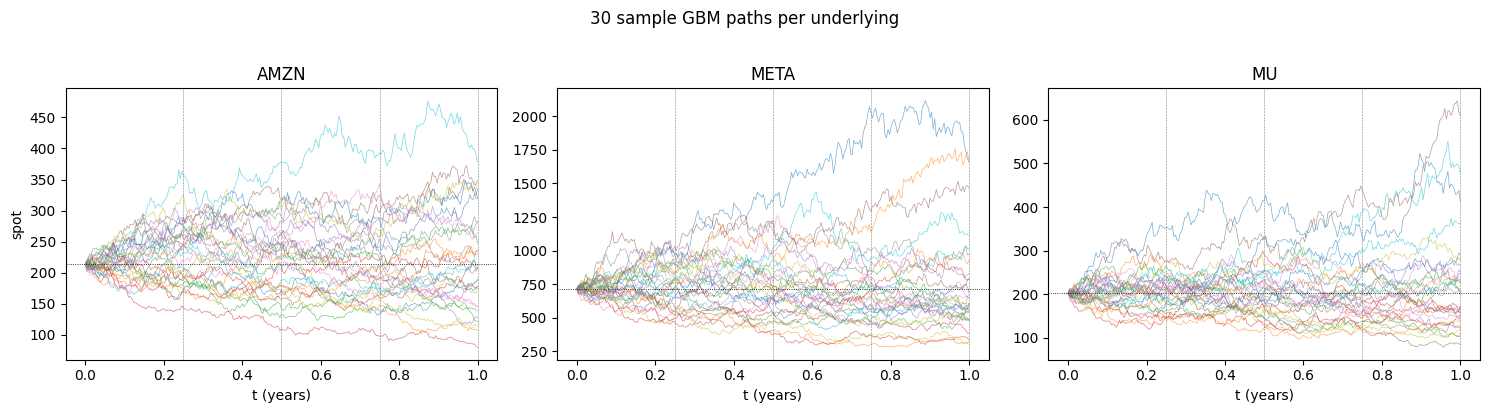

In [5]:
obs_idx = observation_indices(n_steps=n_steps, n_obs=4)
time_grid = np.linspace(0.0, T, n_steps + 1)
obs_times = time_grid[obs_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
n_show = 30
for j, (ax, name) in enumerate(zip(axes, tickers)):
    ax.plot(time_grid, paths[:n_show, :, j].T, lw=0.5, alpha=0.6)
    ax.axhline(spots[j], color="k", lw=0.6, ls=":", label="S(0)")
    for t_obs in obs_times:
        ax.axvline(t_obs, color="grey", lw=0.4, ls="--")
    ax.set_title(name)
    ax.set_xlabel("t (years)")
    if j == 0:
        ax.set_ylabel("spot")
fig.suptitle("30 sample GBM paths per underlying", y=1.02)
plt.tight_layout()
plt.show()

## 5. Worst-of trajectory

Define $W(t) = \min_i S_i(t)/S_i(0)$ along each path. The FCN payoff is entirely driven by this scalar trajectory. Show its distribution at maturity vs. the FCN barriers (knock-in 0.65, coupon 0.70, autocall 1.00).

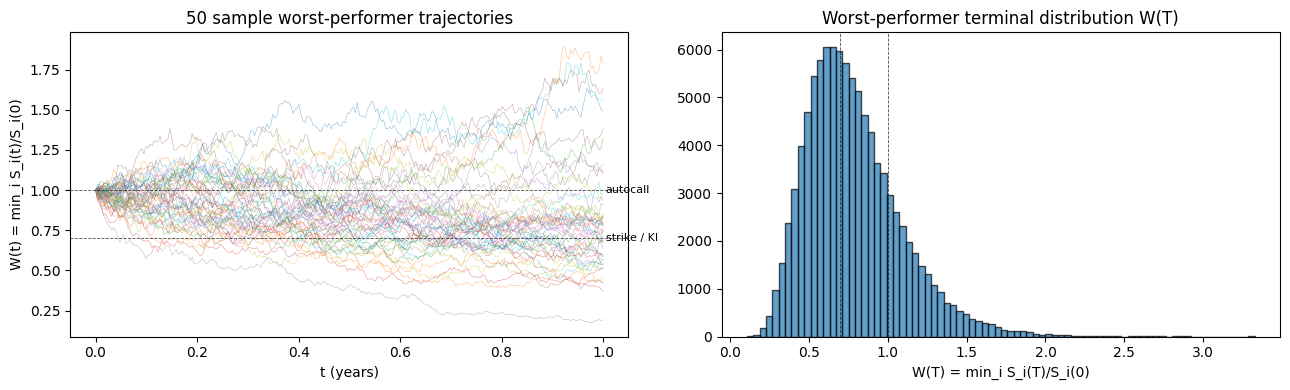

In [6]:
perf = paths / spots               # (paths, steps+1, d)
worst = perf.min(axis=2)            # (paths, steps+1)
worst_T = worst[:, -1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(time_grid, worst[:50].T, lw=0.4, alpha=0.5)
for level, label in [(1.00, "autocall"), (0.70, "strike / KI")]:
    ax1.axhline(level, color="k", lw=0.6, ls="--", alpha=0.7)
    ax1.text(T + 0.005, level, label, va="center", fontsize=8)
ax1.set_title("50 sample worst-performer trajectories")
ax1.set_xlabel("t (years)")
ax1.set_ylabel("W(t) = min_i S_i(t)/S_i(0)")

ax2.hist(worst_T, bins=80, edgecolor="k", alpha=0.7)
for level, label in [(1.00, "autocall"), (0.70, "strike / KI")]:
    ax2.axvline(level, color="k", lw=0.6, ls="--", alpha=0.7)
ax2.set_title("Worst-performer terminal distribution W(T)")
ax2.set_xlabel("W(T) = min_i S_i(T)/S_i(0)")

plt.tight_layout()
plt.show()

## 6. CRN pulse check

Pass the same pre-drawn normals through two configs that differ only in AMZN spot. The difference in paths should isolate the AMZN bump cleanly — useful as a preview of how MC Delta will work.

In [7]:
rng = np.random.default_rng(7)
eta = draw_normals(2_000, n_steps, 3, rng)

cfg_a = SimulationConfig(
    spots=spots, vols=vols, divs=divs, rate=rate, corr=corr,
    T=T, n_steps=n_steps, n_paths=2_000, antithetic=False,
)
spots_up = spots.copy()
spots_up[0] *= 1.01    # +1% AMZN bump
cfg_b = SimulationConfig(
    spots=spots_up, vols=vols, divs=divs, rate=rate, corr=corr,
    T=T, n_steps=n_steps, n_paths=2_000, antithetic=False,
)

paths_a = simulate_paths(cfg_a, normals=eta)
paths_b = simulate_paths(cfg_b, normals=eta)

ratio = paths_b / paths_a
print("Per-path ratio at T, mean / std by underlying:")
print("  mean:", ratio[:, -1, :].mean(axis=0))
print("  std :", ratio[:, -1, :].std(axis=0))
print("Expected: AMZN exactly 1.01 on every path, META/MU exactly 1.0 (independent of eta).")

Per-path ratio at T, mean / std by underlying:
  mean: [1.01 1.   1.  ]
  std : [0. 0. 0.]
Expected: AMZN exactly 1.01 on every path, META/MU exactly 1.0 (independent of eta).


## 7. Sanity checks

If any of these prints `False`, something is broken.

In [8]:
checks = {
    "Empirical log-return mean within 3 SE of theory":
        bool(np.all(np.abs(log_ret.mean(axis=0) - (rate - divs - 0.5 * vols**2) * T)
                    < 3 * log_ret.std(axis=0, ddof=1) / np.sqrt(log_ret.shape[0]))),
    "Empirical log-return stdev within 5% of sigma*sqrt(T)":
        bool(np.all(np.abs(log_ret.std(axis=0, ddof=1) - vols * np.sqrt(T)) / (vols * np.sqrt(T)) < 0.05)),
    "Empirical correlation within 0.02 of input":
        bool(np.all(np.abs(np.corrcoef(log_ret, rowvar=False) - corr) < 0.02)),
    "CRN preserves META/MU exactly across AMZN bump":
        bool(np.allclose(ratio[:, -1, 1], 1.0) and np.allclose(ratio[:, -1, 2], 1.0)),
    "CRN delivers exact 1.01 AMZN bump on every path":
        bool(np.allclose(ratio[:, -1, 0], 1.01)),
}
for desc, ok in checks.items():
    print(f"[{'OK' if ok else 'FAIL'}] {desc}")

[OK] Empirical log-return mean within 3 SE of theory
[OK] Empirical log-return stdev within 5% of sigma*sqrt(T)
[OK] Empirical correlation within 0.02 of input
[OK] CRN preserves META/MU exactly across AMZN bump
[OK] CRN delivers exact 1.01 AMZN bump on every path
